# **Loan Approval Prediction using Artificial Neural Networks (ANN)**

This project focuses on **building an ANN model to predict loan approval status based on applicant details**. It includes data preprocessing, exploratory data analysis (EDA), model building, and evaluation.

## Problem Statement
The goal is to predict whether a loan application will be approved based on applicant details.

## Dataset Overview
- Features: Income, Credit History, Loan Amount, etc.
- Target: Loan_Status (Approved / Not Approved)

**Import Libraries**

In [216]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

**Load dataset**

In [217]:
data = pd.read_csv('/content/loan_approved.csv')

In [218]:
data

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status (Approved)
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


**Basic Checks**

In [219]:
data.shape

(614, 13)

In [220]:
data.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status (Approved)
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [221]:
data.tail()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status (Approved)
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y
613,LP002990,Female,No,0,Graduate,Yes,4583,0.0,133.0,360.0,0.0,Semiurban,N


In [222]:
# info
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Loan_ID                 614 non-null    object 
 1   Gender                  601 non-null    object 
 2   Married                 611 non-null    object 
 3   Dependents              599 non-null    object 
 4   Education               614 non-null    object 
 5   Self_Employed           582 non-null    object 
 6   ApplicantIncome         614 non-null    int64  
 7   CoapplicantIncome       614 non-null    float64
 8   LoanAmount              592 non-null    float64
 9   Loan_Amount_Term        600 non-null    float64
 10  Credit_History          564 non-null    float64
 11  Property_Area           614 non-null    object 
 12  Loan_Status (Approved)  614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [223]:
# columns
data.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area',
       'Loan_Status (Approved)'],
      dtype='object')

In [224]:
# datatype of each column
data.dtypes

,0
Loan_ID,object
Gender,object
Married,object
Dependents,object
Education,object
Self_Employed,object
ApplicantIncome,int64
CoapplicantIncome,float64
LoanAmount,float64
Loan_Amount_Term,float64


In [225]:
# numerical column
data.select_dtypes(include=['int64','float64'])

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
0,5849,0.0,NaN,360.0,1.0
1,4583,1508.0,128.0,360.0,1.0
2,3000,0.0,66.0,360.0,1.0
3,2583,2358.0,120.0,360.0,1.0
4,6000,0.0,141.0,360.0,1.0
...,...,...,...,...,...
609,2900,0.0,71.0,360.0,1.0
610,4106,0.0,40.0,180.0,1.0
611,8072,240.0,253.0,360.0,1.0
612,7583,0.0,187.0,360.0,1.0


In [226]:
# categorical column
data.select_dtypes(include='object')

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,Property_Area,Loan_Status (Approved)
0,LP001002,Male,No,0,Graduate,No,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,Urban,Y
4,LP001008,Male,No,0,Graduate,No,Urban,Y
...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,Urban,Y


In [227]:
# stastitical analysis for numerical data
data.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [228]:
# stastitical analysis for categorical data
data.describe(include='object')

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,Property_Area,Loan_Status (Approved)
count,614,601,611,599,614,582,614,614
unique,614,2,2,4,2,2,3,2
top,LP002990,Male,Yes,0,Graduate,No,Semiurban,Y
freq,1,489,398,345,480,500,233,422


In [229]:
# unique values
A = ['Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed','Property_Area',
       'Loan_Status (Approved)']
for x in A:
  print(x ,'-->',data[x].unique())
  print()

Gender --> ['Male' 'Female' nan]

Married --> ['No' 'Yes' nan]

Dependents --> ['0' '1' '2' '3+' nan]

Education --> ['Graduate' 'Not Graduate']

Self_Employed --> ['No' 'Yes' nan]

Property_Area --> ['Urban' 'Rural' 'Semiurban']

Loan_Status (Approved) --> ['Y' 'N']



In [230]:
# value counts
for x in A:
  print(data[x].value_counts())
  print()

Gender
Male      489
Female    112
Name: count, dtype: int64

Married
Yes    398
No     213
Name: count, dtype: int64

Dependents
0     345
1     102
2     101
3+     51
Name: count, dtype: int64

Education
Graduate        480
Not Graduate    134
Name: count, dtype: int64

Self_Employed
No     500
Yes     82
Name: count, dtype: int64

Property_Area
Semiurban    233
Urban        202
Rural        179
Name: count, dtype: int64

Loan_Status (Approved)
Y    422
N    192
Name: count, dtype: int64



##**Data Cleaning**

In [231]:
# dupliactes
data.duplicated().sum()

np.int64(0)

In [232]:
# check missing values
data.isnull().sum()

,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


There are some missing values.

**Handle Missing values**

**Gender**

In [233]:
# check datatype
data.loc[:,'Gender'].dtype

dtype('O')

In [234]:
# find mode
data.loc[:,'Gender'].mode()[0]

'Male'

In [235]:
# Filling missing values in categorical columns using mode
data.loc[:,'Gender']=data.loc[:,'Gender'].fillna(data.loc[:,'Gender'].mode()[0])

**Married**

In [236]:
# check datatype
data.loc[:,'Married'].dtype

dtype('O')

In [237]:
# find mode
data.loc[:,'Married'].mode()[0]

'Yes'

In [238]:
# Filling missing values in categorical columns using mode
data.loc[:,'Married']=data.loc[:,'Married'].fillna(data.loc[:,'Married'].mode()[0])

**Self_Employed**

In [239]:
# check datatype
data.loc[:,'Self_Employed'].dtype

dtype('O')

In [240]:
# find mode
data.loc[:,'Self_Employed'].mode()[0]

'No'

In [241]:
# Filling missing values in categorical columns using mode
data.loc[:,'Self_Employed']=data.loc[:,'Self_Employed'].fillna(data.loc[:,'Self_Employed'].mode()[0])

**Dependents**

In [242]:
# check datatype
data.loc[:,'Dependents'].dtype

dtype('O')

In [243]:
# find mode
data.loc[:,'Dependents'].mode()[0]

'0'

In [244]:
# Filling missing values in categorical columns using mode
data.loc[:,'Dependents']=data.loc[:,'Dependents'].fillna(data.loc[:,'Dependents'].mode()[0])

In [245]:
# replace 3+ with 3 and do type casting
data.loc[:,'Dependents'] = data.loc[:,'Dependents'].replace({'3+':3})

In [246]:
data.loc[:,'dependents'] = pd.to_numeric(data.loc[:,'Dependents'])

In [247]:
data.loc[:,'dependents'].dtypes

dtype('int64')

In [248]:
data.drop(columns='Dependents',inplace=True)

**Credit_History**

In [249]:
data.loc[:,'Credit_History'].dtype

dtype('float64')

In [250]:
data.loc[:,'Credit_History'].unique()

array([ 1.,  0., nan])

In [251]:
data.loc[:,'Credit_History'].mode()[0]
# since values in credit history is just 0 and 1 , we fill with mode

np.float64(1.0)

In [252]:
data.loc[:,'Credit_History']=data.loc[:,'Credit_History'].fillna(data.loc[:,'Credit_History'].mode()[0])

**Loan_Amount_Term**

In [253]:
data.loc[:,'Loan_Amount_Term'].dtype

dtype('float64')

In [254]:
data.loc[:,'Loan_Amount_Term'].unique()

array([360., 120., 240.,  nan, 180.,  60., 300., 480.,  36.,  84.,  12.])

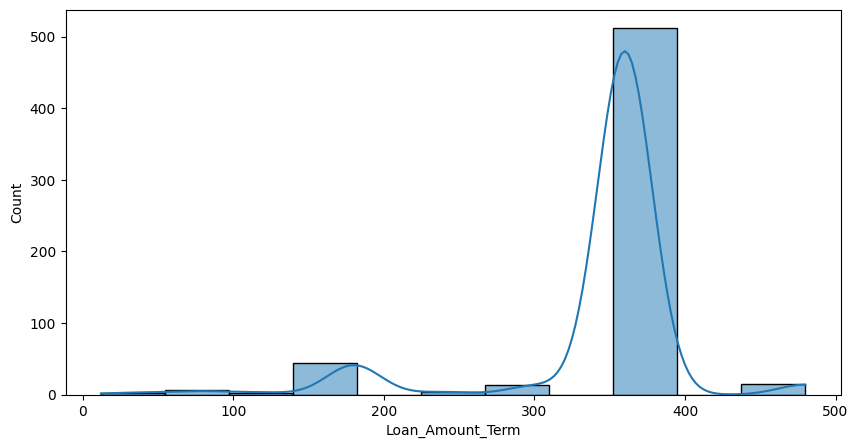

In [255]:
# check the distribution
plt.figure(figsize=(10,5))
sns.histplot(data,x='Loan_Amount_Term', kde=True)
plt.show()

In [256]:
data.loc[:,'Loan_Amount_Term'].skew()

np.float64(-2.362414124216269)

In [257]:
# since distribution is skewed will use median
data.loc[:,'Loan_Amount_Term'].median()

360.0

In [258]:
data.loc[:,'Loan_Amount_Term']=data.loc[:,'Loan_Amount_Term'].fillna(data.loc[:,'Loan_Amount_Term'].median())

**LoanAmount**

In [259]:
data.loc[:,'LoanAmount'].dtype

dtype('float64')

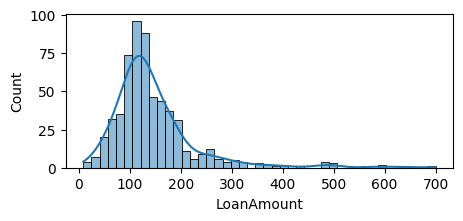

In [260]:
# check the distribution
plt.figure(figsize=(5,2))
sns.histplot(data,x='LoanAmount',kde=True)
plt.show()

In [261]:
data.loc[:,'LoanAmount'].skew()

np.float64(2.677551679256059)

In [262]:
# distribution is skewed
data.loc[:,'LoanAmount'].median()

128.0

In [263]:
data.loc[:,'LoanAmount']=data.loc[:,'LoanAmount'].fillna(data.loc[:,'LoanAmount'].median())

In [264]:
data.isnull().sum()

,0
Loan_ID,0
Gender,0
Married,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0
Credit_History,0


# **Exploratory Data Analysis**

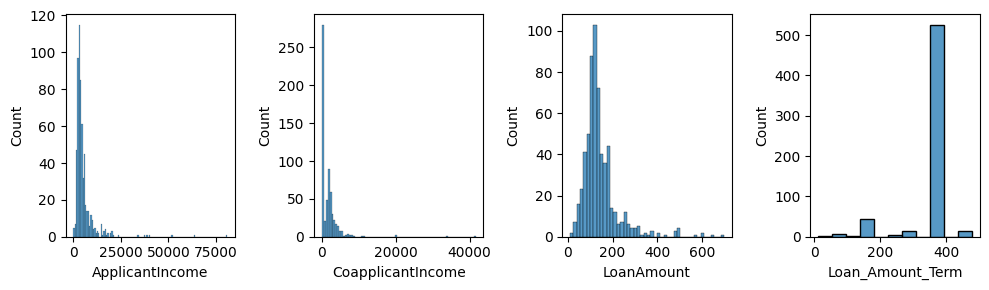

In [265]:
# compare distributions
#ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term
fig,ax = plt.subplots(1,4,figsize=(10,3))
sns.histplot(data,x='ApplicantIncome',ax=ax[0])
sns.histplot(data,x='CoapplicantIncome',ax=ax[1])
sns.histplot(data,x='LoanAmount',ax=ax[2])
sns.histplot(data,x='Loan_Amount_Term',ax=ax[3])
plt.tight_layout()

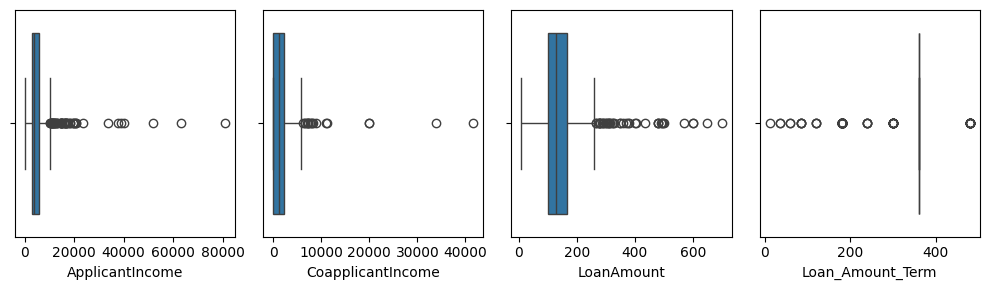

In [266]:
# Box plot
fig,ax = plt.subplots(1,4,figsize=(10,3))
sns.boxplot(data,x='ApplicantIncome',ax=ax[0])
sns.boxplot(data,x='CoapplicantIncome',ax=ax[1])
sns.boxplot(data,x='LoanAmount',ax=ax[2])
sns.boxplot(data,x='Loan_Amount_Term',ax=ax[3])
plt.tight_layout()

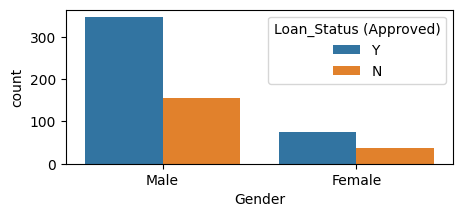

In [267]:
# count plot
# Gender ,Married	,Education,Self_Employed,Credit_History,Property_Area,dependents
plt.figure(figsize=(5,2))
sns.countplot(data,x='Gender',hue='Loan_Status (Approved)')
plt.show()

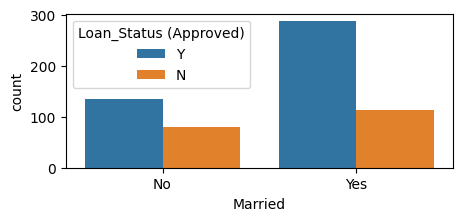

In [268]:
plt.figure(figsize=(5,2))
sns.countplot(data,x='Married',hue='Loan_Status (Approved)')
plt.show()

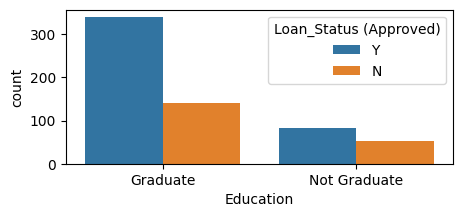

In [269]:
plt.figure(figsize=(5,2))
sns.countplot(data,x='Education',hue='Loan_Status (Approved)')
plt.show()

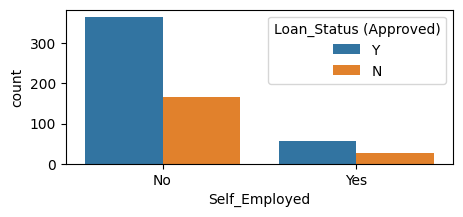

In [270]:
plt.figure(figsize=(5,2))
sns.countplot(data,x='Self_Employed',hue='Loan_Status (Approved)')
plt.show()

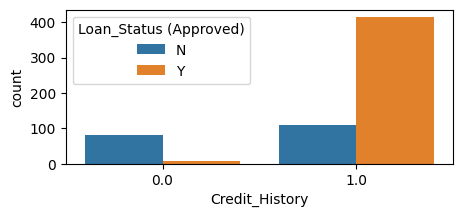

In [271]:
plt.figure(figsize=(5,2))
sns.countplot(data,x='Credit_History',hue='Loan_Status (Approved)')
plt.show()

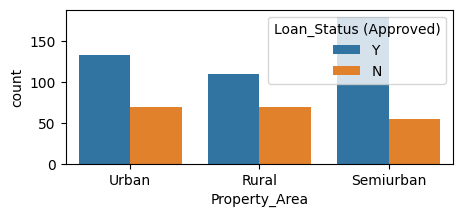

In [272]:
# Property_Area
plt.figure(figsize=(5,2))
sns.countplot(data,x='Property_Area',hue='Loan_Status (Approved)')
plt.show()

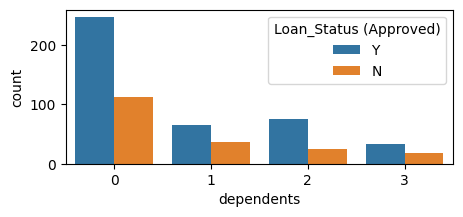

In [273]:
# dependents
plt.figure(figsize=(5,2))
sns.countplot(data,x='dependents',hue='Loan_Status (Approved)')
plt.show()

**Scatter plot**

<Axes: xlabel='LoanAmount', ylabel='Loan_Amount_Term'>

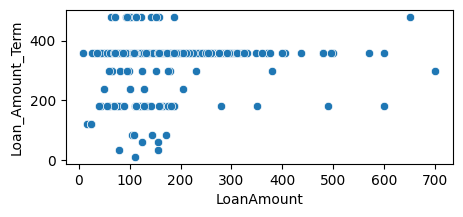

In [274]:
# LoanAmount	 and Loan_Amount_Term
plt.figure(figsize=(5,2))
sns.scatterplot(data,x='LoanAmount',y='Loan_Amount_Term')

<Axes: xlabel='ApplicantIncome', ylabel='LoanAmount'>

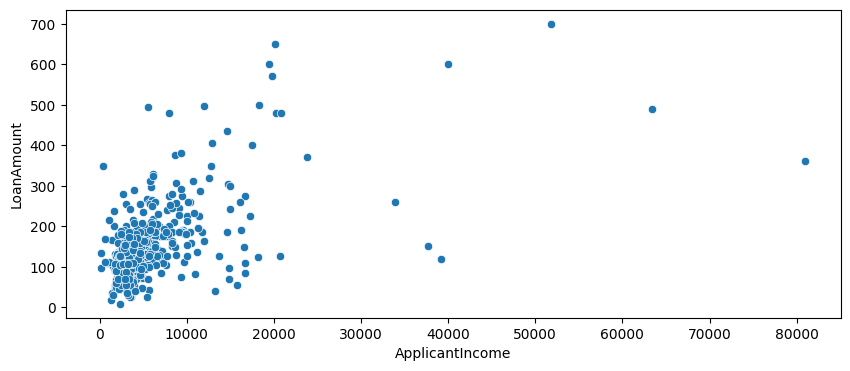

In [275]:
# ApplicantIncome v/s LoanAmount
plt.figure(figsize=(10,4))
sns.scatterplot(data,x='ApplicantIncome',y='LoanAmount')

<Axes: xlabel='CoapplicantIncome', ylabel='LoanAmount'>

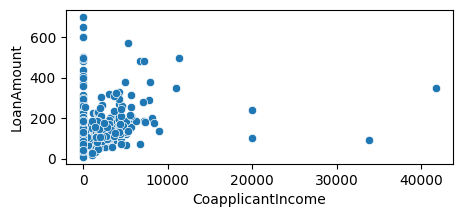

In [276]:
# CoapplicantIncome v/s LoanAmount
plt.figure(figsize=(5,2))
sns.scatterplot(data,x='CoapplicantIncome',y='LoanAmount')

##**Handle Outliers**

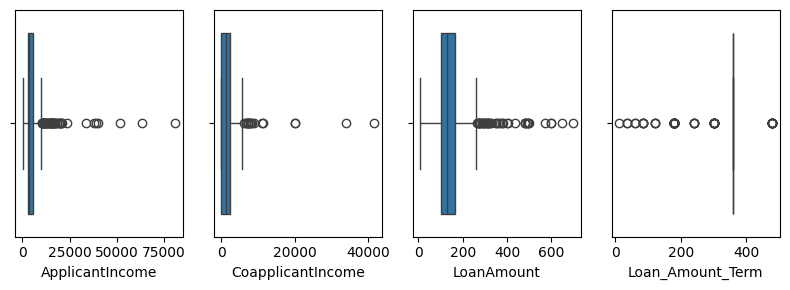

In [277]:
# Box plot
fig,ax = plt.subplots(1,4,figsize=(8,3))
sns.boxplot(data,x='ApplicantIncome',ax=ax[0])
sns.boxplot(data,x='CoapplicantIncome',ax=ax[1])
sns.boxplot(data,x='LoanAmount',ax=ax[2])
sns.boxplot(data,x='Loan_Amount_Term',ax=ax[3])
plt.tight_layout()

In [278]:
A = ['ApplicantIncome','CoapplicantIncome','LoanAmount','Loan_Amount_Term']
for x in A:
  print(x,data[x].skew())

ApplicantIncome 6.539513113994625
CoapplicantIncome 7.491531216657306
LoanAmount 2.743052748820892
Loan_Amount_Term -2.4021122563890396


Since distribution of all numerical column is skewed we use **IQR method**

**ApplicantIncome**

In [279]:
Q1 = data.loc[:,'ApplicantIncome'].quantile(0.25)
Q3 = data.loc[:,'ApplicantIncome'].quantile(0.75)
IQR = Q3 - Q1
lower_limit = Q1-1.5*IQR
upper_limit = Q3+1.5*IQR
print(lower_limit,upper_limit)

-1498.75 10171.25


In [280]:
data[(data.loc[:,'ApplicantIncome']>upper_limit)| (data.loc[:,'ApplicantIncome']<lower_limit)]

,Loan_ID,Gender,Married,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status (Approved),dependents
9,LP001020,Male,Yes,Graduate,No,12841,10968.0,349.0,360.0,1.0,Semiurban,N,1
34,LP001100,Male,No,Graduate,No,12500,3000.0,320.0,360.0,1.0,Rural,N,3
54,LP001186,Female,Yes,Graduate,Yes,11500,0.0,286.0,360.0,0.0,Urban,N,1
67,LP001233,Male,Yes,Graduate,No,10750,0.0,312.0,360.0,1.0,Urban,Y,1
102,LP001350,Male,Yes,Graduate,No,13650,0.0,128.0,360.0,1.0,Urban,Y,0
106,LP001369,Male,Yes,Graduate,No,11417,1126.0,225.0,360.0,1.0,Urban,Y,2
115,LP001401,Male,Yes,Graduate,No,14583,0.0,185.0,180.0,1.0,Rural,Y,1
119,LP001422,Female,No,Graduate,No,10408,0.0,259.0,360.0,1.0,Urban,Y,0
126,LP001448,Male,Yes,Graduate,No,23803,0.0,370.0,360.0,1.0,Rural,Y,3
128,LP001451,Male,Yes,Graduate,Yes,10513,3850.0,160.0,180.0,0.0,Urban,N,1


In [281]:
len(data[(data.loc[:,'ApplicantIncome']>upper_limit)| (data.loc[:,'ApplicantIncome']<lower_limit)])/len(data)*100

8.143322475570033

**CoapplicantIncome**

In [282]:
Q1 = data.loc[:,'CoapplicantIncome'].quantile(0.25)
Q3 = data.loc[:,'CoapplicantIncome'].quantile(0.75)
IQR = Q3 - Q1
lower_limit = Q1-1.5*IQR
upper_limit = Q3+1.5*IQR
print(lower_limit,upper_limit)

-3445.875 5743.125


In [283]:
data[(data.loc[:,'CoapplicantIncome']>upper_limit)| (data.loc[:,'CoapplicantIncome']<lower_limit)]

,Loan_ID,Gender,Married,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status (Approved),dependents
9,LP001020,Male,Yes,Graduate,No,12841,10968.0,349.0,360.0,1.0,Semiurban,N,1
12,LP001028,Male,Yes,Graduate,No,3073,8106.0,200.0,360.0,1.0,Urban,Y,2
38,LP001114,Male,No,Graduate,No,4166,7210.0,184.0,360.0,1.0,Urban,Y,0
122,LP001431,Female,No,Graduate,No,2137,8980.0,137.0,360.0,0.0,Semiurban,Y,0
135,LP001488,Male,Yes,Graduate,No,4000,7750.0,290.0,360.0,1.0,Semiurban,N,3
177,LP001610,Male,Yes,Graduate,No,5516,11300.0,495.0,360.0,0.0,Semiurban,N,3
180,LP001633,Male,Yes,Graduate,No,6400,7250.0,180.0,360.0,0.0,Urban,N,1
253,LP001843,Male,Yes,Not Graduate,No,2661,7101.0,279.0,180.0,1.0,Semiurban,Y,1
349,LP002138,Male,Yes,Graduate,No,2625,6250.0,187.0,360.0,1.0,Rural,Y,0
372,LP002201,Male,Yes,Graduate,Yes,9323,7873.0,380.0,300.0,1.0,Rural,Y,2


In [284]:
len(data[(data.loc[:,'CoapplicantIncome']>upper_limit)| (data.loc[:,'CoapplicantIncome']<lower_limit)])/len(data)*100

2.9315960912052117

In [285]:
# Missing values handled using median
data.loc[(data.loc[:,'CoapplicantIncome']>upper_limit)|
 (data.loc[:,'CoapplicantIncome']<lower_limit),
         'CoapplicantIncome']=data.loc[:,'CoapplicantIncome'].median()

**LoanAmount**

In [286]:
Q1 = data.loc[:,'LoanAmount'].quantile(0.25)
Q3 = data.loc[:,'LoanAmount'].quantile(0.75)
IQR = Q3 - Q1
lower_limit = Q1-1.5*IQR
upper_limit = Q3+1.5*IQR
print(lower_limit,upper_limit)

3.5 261.5


In [287]:
data[(data.loc[:,'LoanAmount']>upper_limit)| (data.loc[:,'LoanAmount']<lower_limit)]

,Loan_ID,Gender,Married,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status (Approved),dependents
5,LP001011,Male,Yes,Graduate,Yes,5417,4196.0,267.0,360.0,1.0,Urban,Y,2
9,LP001020,Male,Yes,Graduate,No,12841,1188.5,349.0,360.0,1.0,Semiurban,N,1
21,LP001046,Male,Yes,Graduate,No,5955,5625.0,315.0,360.0,1.0,Urban,Y,1
34,LP001100,Male,No,Graduate,No,12500,3000.0,320.0,360.0,1.0,Rural,N,3
54,LP001186,Female,Yes,Graduate,Yes,11500,0.0,286.0,360.0,0.0,Urban,N,1
67,LP001233,Male,Yes,Graduate,No,10750,0.0,312.0,360.0,1.0,Urban,Y,1
83,LP001273,Male,Yes,Graduate,No,6000,2250.0,265.0,360.0,1.0,Semiurban,N,0
126,LP001448,Male,Yes,Graduate,No,23803,0.0,370.0,360.0,1.0,Rural,Y,3
130,LP001469,Male,No,Graduate,Yes,20166,0.0,650.0,480.0,1.0,Urban,Y,0
135,LP001488,Male,Yes,Graduate,No,4000,1188.5,290.0,360.0,1.0,Semiurban,N,3


In [288]:
len(data[(data.loc[:,'LoanAmount']>upper_limit)| (data.loc[:,'LoanAmount']<lower_limit)])/len(data)*100

6.677524429967427

**Loan_Amount_Term**

In [289]:
Q1 = data.loc[:,'Loan_Amount_Term'].quantile(0.25)
Q3 = data.loc[:,'Loan_Amount_Term'].quantile(0.75)
IQR = Q3 - Q1
lower_limit = Q1-1.5*IQR
upper_limit = Q3+1.5*IQR
print(lower_limit,upper_limit)

360.0 360.0


In [290]:
data[(data.loc[:,'Loan_Amount_Term']>upper_limit)| (data.loc[:,'Loan_Amount_Term']<lower_limit)]

,Loan_ID,Gender,Married,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status (Approved),dependents
14,LP001030,Male,Yes,Graduate,No,1299,1086.0,17.0,120.0,1.0,Urban,Y,2
16,LP001034,Male,No,Not Graduate,No,3596,0.0,100.0,240.0,1.0,Urban,Y,1
62,LP001207,Male,Yes,Not Graduate,Yes,2609,3449.0,165.0,180.0,0.0,Rural,N,0
66,LP001228,Male,No,Not Graduate,No,3200,2254.0,126.0,180.0,0.0,Urban,N,0
68,LP001238,Male,Yes,Not Graduate,Yes,7100,0.0,125.0,60.0,1.0,Urban,Y,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...
591,LP002931,Male,Yes,Graduate,Yes,6000,0.0,205.0,240.0,1.0,Semiurban,N,2
593,LP002936,Male,Yes,Graduate,No,3859,3300.0,142.0,180.0,1.0,Rural,Y,0
600,LP002949,Female,No,Graduate,No,416,1188.5,350.0,180.0,1.0,Urban,N,3
605,LP002960,Male,Yes,Not Graduate,No,2400,3800.0,128.0,180.0,1.0,Urban,N,0


In [291]:
len(data[(data.loc[:,'Loan_Amount_Term']>upper_limit)| (data.loc[:,'Loan_Amount_Term']<lower_limit)])/len(data)*100

14.332247557003258

**Encoding**

In [292]:
# Gender --> one hot encoding
data = pd.get_dummies(data,columns=['Gender'],dtype='int')
data

,Loan_ID,Married,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status (Approved),dependents,Gender_Female,Gender_Male
0,LP001002,No,Graduate,No,5849,0.0,128.0,360.0,1.0,Urban,Y,0,0,1
1,LP001003,Yes,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N,1,0,1
2,LP001005,Yes,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y,0,0,1
3,LP001006,Yes,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y,0,0,1
4,LP001008,No,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,No,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y,0,1,0
610,LP002979,Yes,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y,3,0,1
611,LP002983,Yes,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y,1,0,1
612,LP002984,Yes,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y,2,0,1


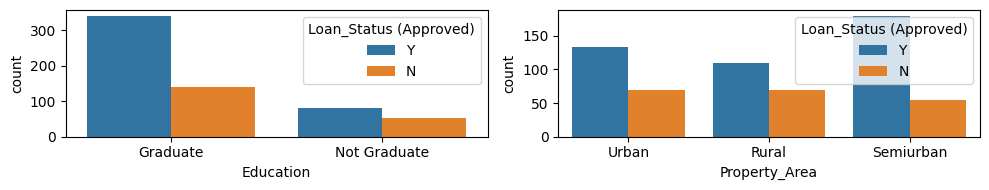

In [293]:
# Education , Property_Area
fig,ax = plt.subplots(1,2,figsize=(10,2))
sns.countplot(data,x = 'Education',ax=ax[0],hue='Loan_Status (Approved)')
sns.countplot(data,x = 'Property_Area',ax=ax[1],hue='Loan_Status (Approved)')
plt.tight_layout()

In [294]:
# Manual Encoding
data.loc[:,'education']=data.loc[:,'Education'].map(
    {'Graduate':1,'Not Graduate':0})

In [295]:
data.loc[:,'property_area']=data.loc[:,'Property_Area'].map(
    {'Urban':1,'Semiurban':2,'Rural':0})


In [296]:
# Married , Self_Employed, Loan_Status (Approved)--> Label Encoder
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
data.loc[:,'married']=le.fit_transform(data.loc[:,'Married'])
data.loc[:,'self_employed'] = le.fit_transform(data.loc[:,'Self_Employed'])
data.loc[:,'Loan_status'] = le.fit_transform(data.loc[:,'Loan_Status (Approved)'])

In [297]:
data.drop(columns=['Married','Education','Self_Employed','Property_Area',
                   'Loan_Status (Approved)'],inplace=True)

**Scaling**


Feature scaling applied for ANN convergence

In [298]:
# ApplicantIncome CoapplicantIncome	LoanAmount	Loan_Amount_Term
from sklearn.preprocessing import StandardScaler
model = StandardScaler()
data[['ApplicantIncome']]=model.fit_transform(data[['ApplicantIncome']])
data[['CoapplicantIncome']]=model.fit_transform(data[['CoapplicantIncome']])
data[['LoanAmount']]=model.fit_transform(data[['LoanAmount']])
data[['Loan_Amount_Term']]=model.fit_transform(data[['Loan_Amount_Term']])

##**Feature Engineering**

In [299]:
data.drop(columns='Loan_ID',inplace=True)

**Split Data**

In [300]:
x= data.drop(columns ='Loan_status')
y = data.loc[:,'Loan_status']

**Split data into training and testing**

In [301]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size =0.2,random_state=42)

##**Balance data**

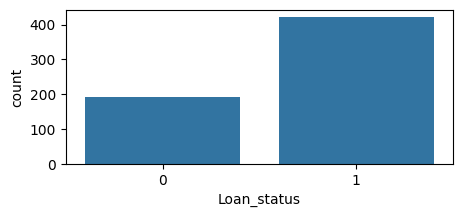

In [302]:
plt.figure(figsize=(5,2))
sns.countplot(data, x='Loan_status')
plt.show()

In [304]:
# smote
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
x_sampled,y_sampled=smote.fit_resample(x_train,y_train)

In [307]:
from collections import Counter
Counter(y)

Counter({1: 422, 0: 192})

In [308]:
Counter(y_sampled)

Counter({0: 342, 1: 342})

##**ANN Classifier**

ANN chosen to capture non-linear relationships

In [309]:
# MLP : Multi layer perception
from sklearn.neural_network import MLPClassifier
model = MLPClassifier(hidden_layer_sizes=50,activation='relu',solver='adam')
model.fit(x_sampled,y_sampled)

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPClassifier(hidden_layer_sizes=50)

ReLU used for hidden layers (avoids vanishing gradient)

In [310]:
y_pred =model.predict(x_test)

##**Model Evaluation**


**Import Libraries for evaluation**

In [327]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,recall_score,precision_score,f1_score,roc_curve,auc

In [322]:
cm =confusion_matrix(y_test,y_pred)
cm

array([[22, 21],
       [11, 69]])

In [313]:
accuracy_score(y_test,y_pred)

0.7398373983739838

In [317]:
recall_score(y_test,y_pred)

0.8625

In [319]:
precision_score(y_test,y_pred)

0.7666666666666667

In [321]:
f1_score(y_test,y_pred)

0.8117647058823529

**Interpretation**

- The model achieves an accuracy of around 74%, indicating decent performance.
- High recall (86%) shows the model is good at identifying positive cases (loan approvals).
- Precision (76%) indicates that most predicted approvals are correct, though some false positives exist.
- F1 score (~0.81) suggests a good balance between precision and recall.
- The confusion matrix shows that the model performs better in predicting approved cases compared to rejected ones.

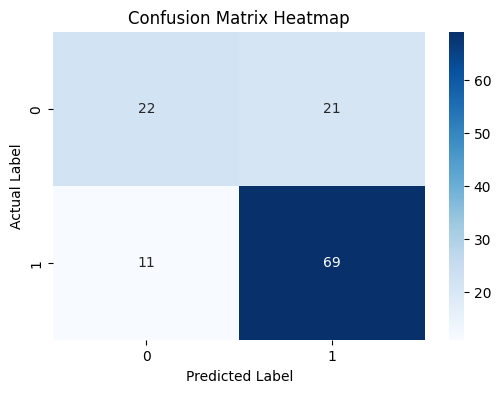

In [323]:
# Confusion matrix
# Plot heatmap
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix Heatmap")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

**Insight**

- The heatmap visually shows True Positives, True Negatives, False Positives, and False Negatives

- Helps quickly understand where the model is making mistakes

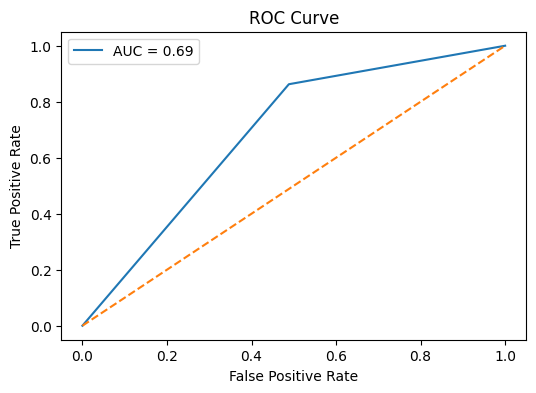

In [328]:
# ROC values
fpr, tpr, thresholds = roc_curve(y_test, y_pred)
# AUC score
roc_auc = auc(fpr, tpr)
# Plot ROC Curve
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], linestyle='--')  # Diagonal line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

##**Conclusion**

In this project, an **Artificial Neural Network (ANN)** model was successfully developed to predict loan approval status based on applicant details. The workflow included **data preprocessing, handling missing values, exploratory data analysis (EDA), feature preparation, model building, and evaluation**.

The model achieved an **accuracy of approximately 74%**, with a** high recall score**, indicating that it performs well in identifying loan approvals. The **F1 score shows a good balance between precision and recall**, making the model reasonably reliable for prediction tasks.

Overall, the ANN model was able to learn meaningful patterns from the dataset. Features such as **credit history and applicant-related attributes** played a significant role in prediction.

##**Final Outcome**

The project demonstrates the **end-to-end implementation of a machine learning pipeline using ANN**, including data preprocessing, analysis, model training, and evaluation. The model provides a **baseline solution for loan approval prediction**, which can be further improved with advanced techniques.